In [1]:
%run -i ./01_definitions.ipynb
%matplotlib widget

We can always factor a joint probability density into a conditional and an unconditional factor:

$$p(\mathbf{x}, \mathbf{y}) = p(\mathbf{x}|\mathbf{y})\,p(\mathbf{y}) = p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x}). \tag{2.8}$$

This one statement has important ramifications.

First, the process of integrating out one or more variables from a joint density, $p(\mathbf{x}, \mathbf{y})$, is called *marginalization*. For example, integrating the joint density over $\mathbf{x}$ reveals

$$\int p(\mathbf{x}, \mathbf{y})\,d\mathbf{x} = \int p(\mathbf{x}|\mathbf{y})\,p(\mathbf{y})\,d\mathbf{x} = \underbrace{\int p(\mathbf{x}|\mathbf{y})\,d\mathbf{x}}_{1}\, p(\mathbf{y}) = p(\mathbf{y}). \tag{2.9}$$

The result, $p(\mathbf{y})$, is the *marginal* of the joint density for $\mathbf{y}$. Clearly then, the marginal for $\mathbf{x}$ is $p(\mathbf{x}) = \int p(\mathbf{x}, \mathbf{y})\,d\mathbf{y}$.

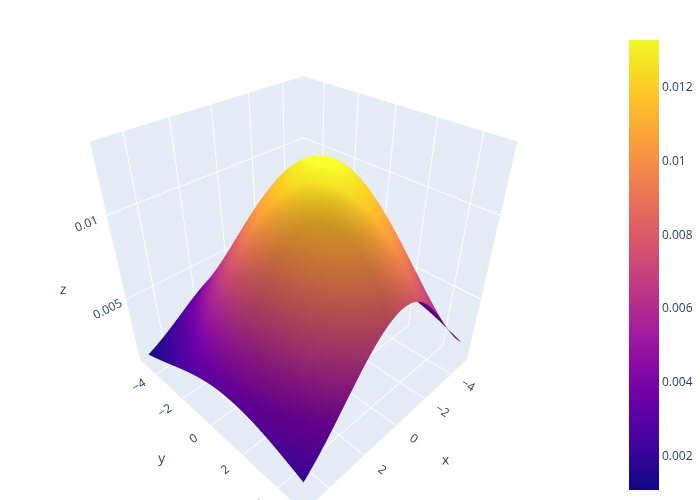

In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  fxy = _ContinuousFunction(f=lambda x, y: (x, y))
  pxy = _ContinuousFunction(f=lambda x, y:
                            _ContinuousFunction(_gaussian(0.0, 3.0))(x) *
                            _ContinuousFunction(_gaussian(1.0, 4.0))(y))
  xy = _ContinuousRandomEvent(f=fxy, p=pxy)
  _plot_surface(xy.p)

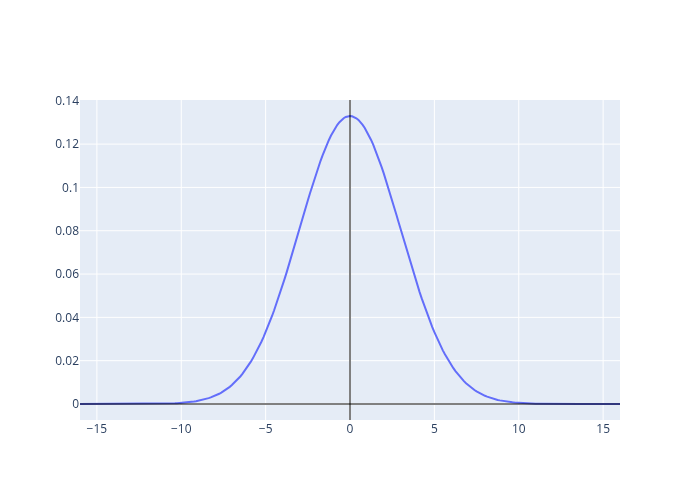

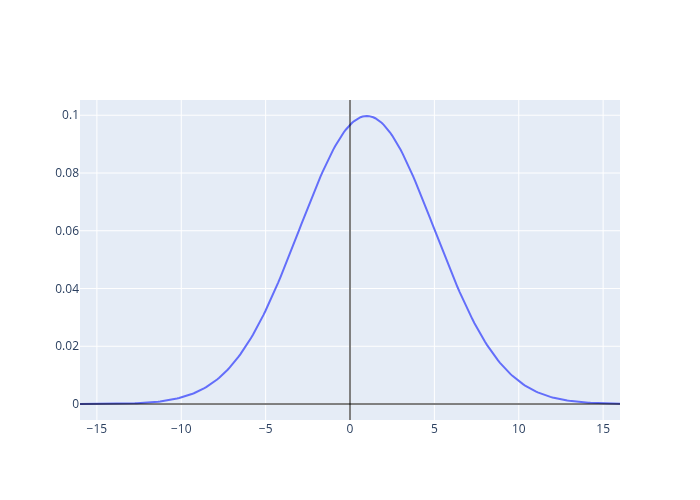

In [13]:
if __name__ == '__main__' and '__file__' not in globals():
  px_from_pxy = _ContinuousFunction(
    # p(x)
    f=(lambda x: (
      # ∫ p(x, y) dy
      _ContinuousFunction(
        f=(lambda y: (
          pxy(x, y)
        )), bounds=[(-128.0, 128.0)]
      ).integrate()
    )), bounds = [(-128.0, 128.0)]
  )  
  _plot_function(px_from_pxy)

  py_from_pxy = _ContinuousFunction(
    # p(y)
    f=(lambda y: (
      # ∫ p(x, y) dx
      _ContinuousFunction(
        f=(lambda x: (
          pxy(x, y)
        )), bounds=[(-128.0, 128.0)]
      ).integrate()
    )), bounds=[(-128.0, 128.0)]
  )
  _plot_function(py_from_pxy)

Second, rearranging (2.8) gives *Bayes' rule* (a.k.a., Bayes' theorem):

$$p(\mathbf{x}|\mathbf{y}) = \frac{p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x})}{p(\mathbf{y})}. \tag{2.10}$$

We can use this to *infer* the *posterior* or likelihood of the state given some measurements, $p(\mathbf{x}|\mathbf{y})$, if we have a *prior* PDF over the state, $p(\mathbf{x})$, and the sensor model, $p(\mathbf{y}|\mathbf{x})$. We do this by expanding the denominator so that

$$p(\mathbf{x}|\mathbf{y}) = \frac{p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x})}{\int p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}}. \tag{2.11}$$

We compute the denominator, $p(\mathbf{y})$, by marginalization as follows:

$$p(\mathbf{y}) = \int p(\mathbf{x}, \mathbf{y})\,d\mathbf{x} = \int p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}, \tag{2.12}$$

which can be quite expensive to calculate in the general case. In Bayesian inference, $p(\mathbf{x})$ is known as the *prior* density, while $p(\mathbf{x}|\mathbf{y})$ is known as the *posterior* density. Thus, all *a priori* information is encapsulated in $p(\mathbf{x})$, while $p(\mathbf{x}|\mathbf{y})$ contains the *a posteriori* information.

In [31]:
def _posterior(prior:_ContinuousFunction, likelihood:_ContinuousFunction):
  # prior -> p(x)
  # likelihood -> p(y|x)
  # evidence -> p(y) -> ∫((p(y|x) p(x)) dx)

  evidence = _ContinuousFunction(f=(lambda y: (
    _ContinuousFunction(f=(lambda x: (
      (likelihood(y, x) * prior(x))
    )), bounds=[(-128.0, 128.0)]).integrate()
  )), bounds=[(-128.0, 128.0)])

  return _ContinuousFunction(f=(lambda x, y: (
    (likelihood(y, x) * prior(x)) / evidence(y)
  )), bounds=[(-128.0, 128.0)])

<center>

**Testing/Playground Below** 

<small><em>
(always wrap with `if __name__ == '__main__' and '__file__' not in globals():`)
</em></small>

</center>

In [11]:
# explore: given an initial assumption of a location of something, and a reading on a noisy sensor about the location of that object, update the assumption of the location of the object

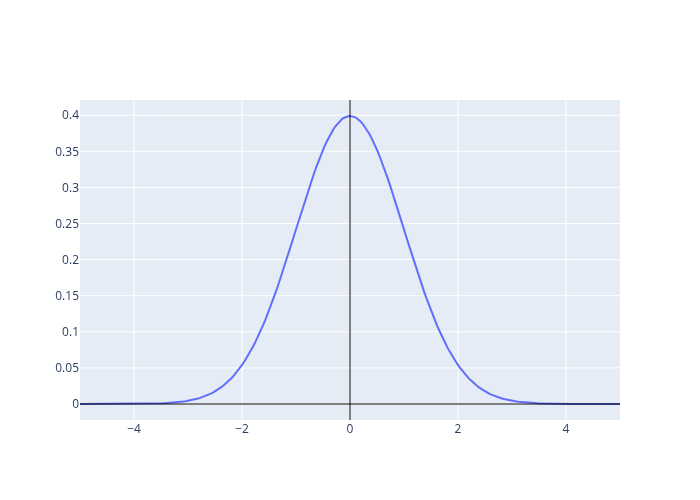

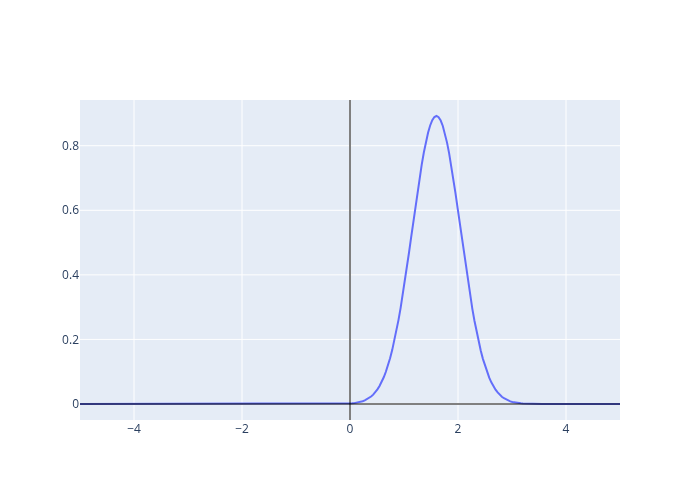

In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  #initial guess, 95% confidence that thing is between -2 and 2, with gaussian spread
  location = _ContinuousRandomEvent(f=_ContinuousFunction(),
                                       p=_ContinuousFunction(f=_gaussian(0.0, 1.0)),
                                       bounds=[(-128.0, 128.0)])
  _plot_function(location.p, (-5.0, 5.0))
  
  #sensor probability of reading is dependent on actual location, and sensor reading is 95% sure to display within += 4 units away from actual location
  sensor_p = _ContinuousFunction(f=lambda reading, trueloc: (
    _gaussian(trueloc, 0.5)(reading)
  ), bounds=[(-128.0, 128.0), (-128.0, 128.0)])

  reading = 2.0 #location sensor reads 2.0

  #update belief about actual location based on sensor reading
  loc_p_given_sensor = _posterior(prior=location.p, likelihood=sensor_p)
  new_location_p = lambda x: loc_p_given_sensor(x, reading)
  _plot_function(new_location_p, (-5.0, 5.0))

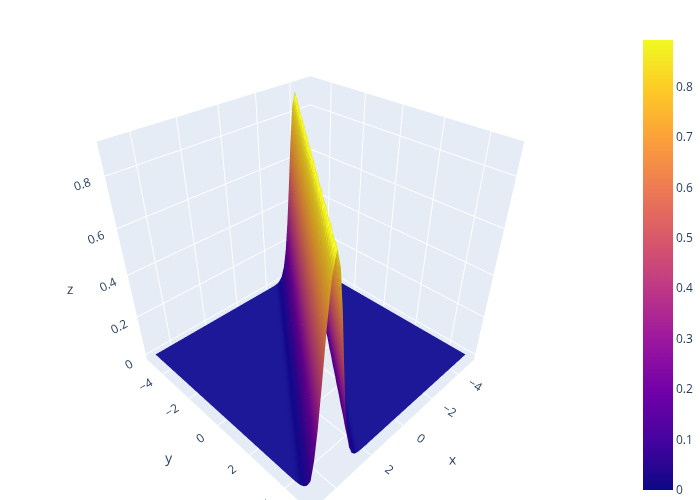

In [55]:
if __name__ == '__main__' and '__file__' not in globals():
  _plot_surface(loc_p_given_sensor)